# Tutorial 7 - SOH-R

In [1]:
import matplotlib.pyplot as plt

import pydpeet as eet

eet.set_logging_style("ERROR")

In [2]:
Datas = eet.read(config="neware_8_0_0_516", input_path=r"..\..\res\raw")
Data = eet.merge_into_series(Datas)

In [3]:
Data_segmented = eet.add_primitive_segments(Data)
Data.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],TestIndex
0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0.0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None,0.0
1,None,0.0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None,0.0
2,None,0.0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None,0.0
3,None,0.0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None,0.0
4,None,0.0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None,0.0


In [4]:
Battery_Config = eet.lgm50lt_nmc_4800

# todo: is it possible to probide acces to the Batemo/About-Energy database and fetch battery configs directly from there?
# todo: or we download it and provide the databse directly?

Data = eet.add_resistance_internal(Data, config=Battery_Config)
Data.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],TestIndex,InternalResistance[ohm]
0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0.0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None,0.0,NaN
1,None,0.0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None,0.0,NaN
2,None,0.0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None,0.0,NaN
3,None,0.0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None,0.0,NaN
4,None,0.0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None,0.0,NaN


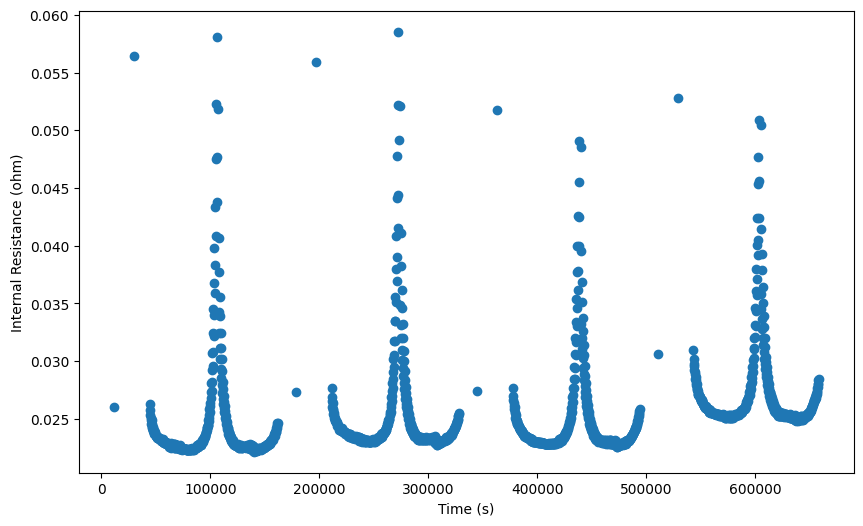

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(Data["Test_Time[s]"], Data["InternalResistance[ohm]"])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Internal Resistance (ohm)")
plt.show()